# Лабораторная работа 5. Метод опорных векторов и деревья решений в задачах классификации и регрессии

## Примерная структура блокнота для задания 1

### 1. Подготовка среды

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Настройка графиков
plt.rcParams['figure.figsize'] = (8, 6)
%matplotlib inline

### 2. Генерация и визуализация наборов данных

Создайте три разных набора данных:

#### 2.1. Линейно разделимый набор

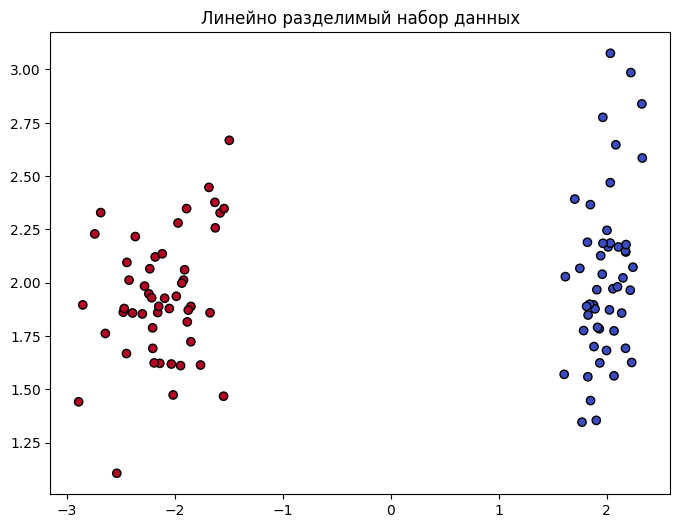

In [2]:
# Генерация данных
X1, y1 = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2.0,  # увеличенное разделение
    random_state=1
)

# Визуализация
plt.scatter(X1[:, 0], X1[:, 1], c=y1, cmap='coolwarm', edgecolors='k')
plt.title('Линейно разделимый набор данных')
plt.show()

#### 2.2. Набор с шумом (перекрытие классов)

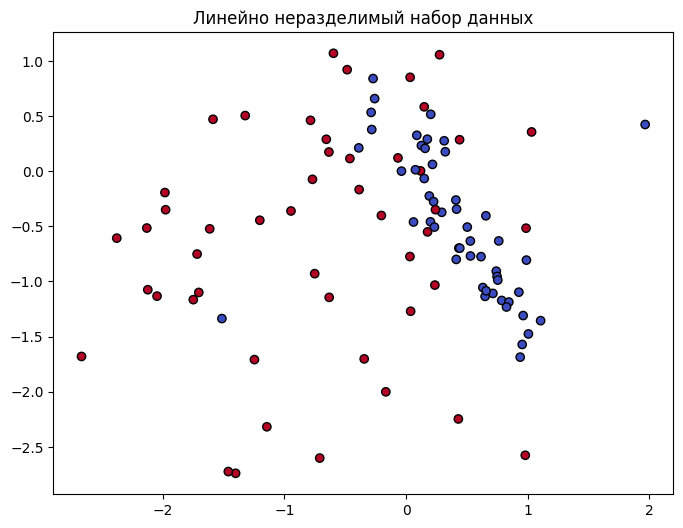

In [3]:
# Ваш код здесь
# Подсказка: используйте параметр `flip_y` или уменьшите `class_sep`
# Генерация данных
X2, y2 = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=10,
    class_sep=0.5,
    flip_y=0.1
)

# Визуализация
plt.scatter(X2[:, 0], X2[:, 1], c=y2, cmap='coolwarm', edgecolors='k')
plt.title('Линейно неразделимый набор данных')
plt.show()

#### 2.3. Нелинейно разделимый набор

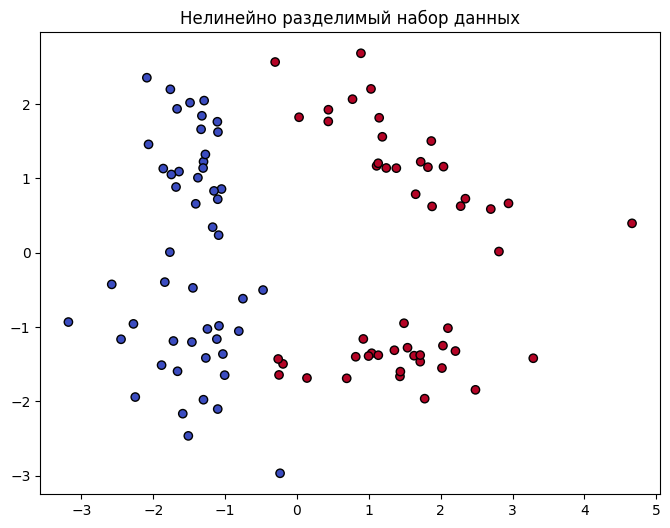

In [4]:
# Ваш код здесь
X3, y3 = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=2,
    random_state=10,
    flip_y=0,
    class_sep=1.4
)

# Визуализация
plt.scatter(X3[:, 0], X3[:, 1], c=y3, cmap='coolwarm', edgecolors='k')
plt.title('Нелинейно разделимый набор данных')
plt.show()

### 3. Обучение SVM на разных ядрах

3.1. Напишите функцию для обучения SVM и визуализации границы принятия решений:

In [5]:
def plot_svm_decision_boundary(X, y, kernel='rbf', C=1.0, gamma='scale', title=''):
    # Масштабирование
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Обучение модели
    clf = svm.SVC(kernel=kernel, C=C, gamma=gamma)
    clf.fit(X_scaled, y)

    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=50)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)
    
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    plt.title(title)
    plt.show()
    
    # Точность
    y_pred = clf.predict(X_scaled)
    acc = accuracy_score(y, y_pred)
    print(f"Точность ({kernel}): {acc:.3f}")
    return clf

3.2. Примените созданную функцию к каждому набору данных с разными ядрами:

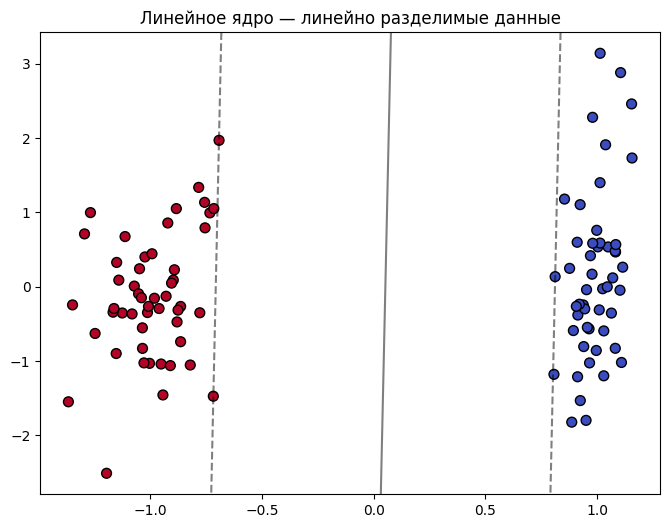

Точность (linear): 1.000


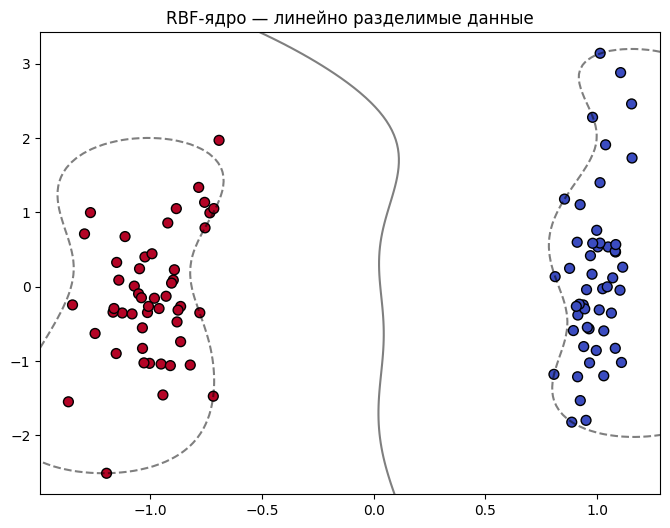

Точность (rbf): 1.000


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [6]:
# Пример для первого набора
plot_svm_decision_boundary(X1, y1, kernel='linear', title='Линейное ядро — линейно разделимые данные')
plot_svm_decision_boundary(X1, y1, kernel='rbf', title='RBF-ядро — линейно разделимые данные')

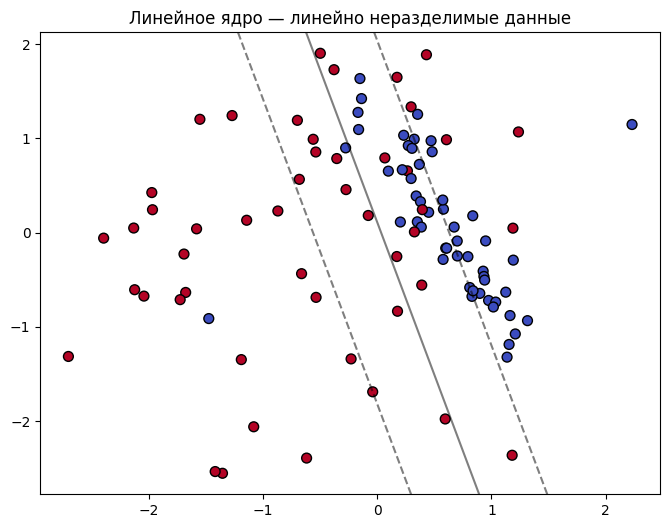

Точность (linear): 0.830


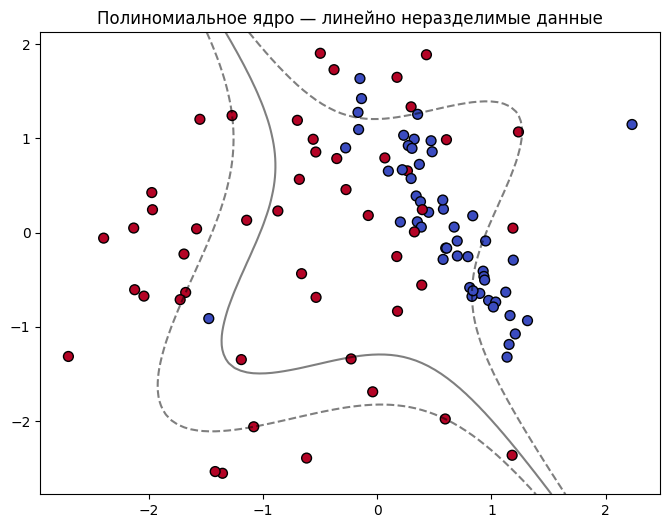

Точность (poly): 0.730


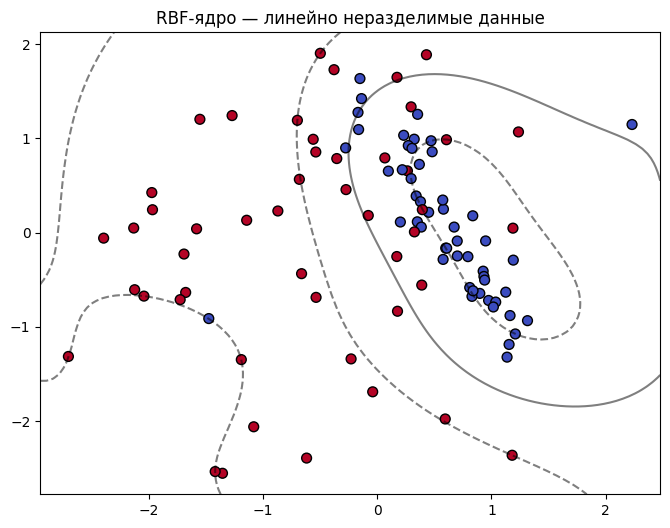

Точность (rbf): 0.830


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [7]:
# Пример для первого набора
plot_svm_decision_boundary(X2, y2, kernel='linear', title='Линейное ядро — линейно неразделимые данные')
plot_svm_decision_boundary(X2, y2, kernel='poly', title='Полиномиальное ядро — линейно неразделимые данные')
plot_svm_decision_boundary(X2, y2, kernel='rbf', title='RBF-ядро — линейно неразделимые данные')

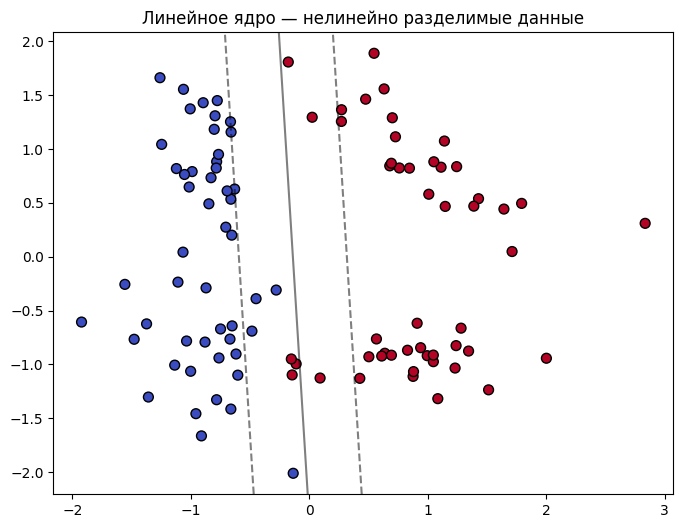

Точность (linear): 0.970


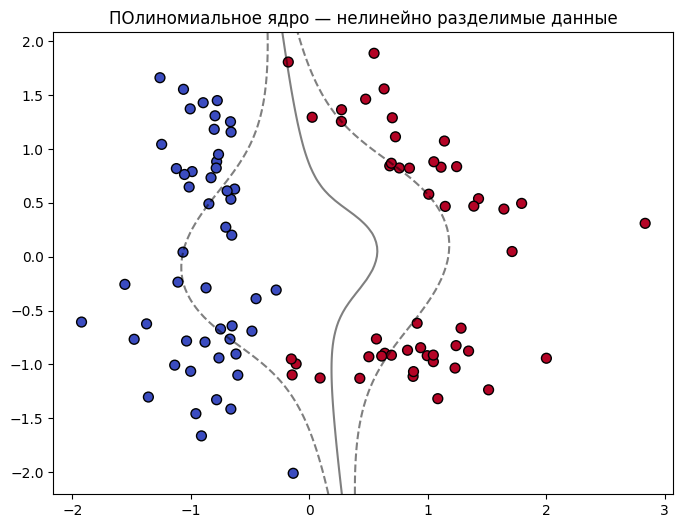

Точность (poly): 0.960


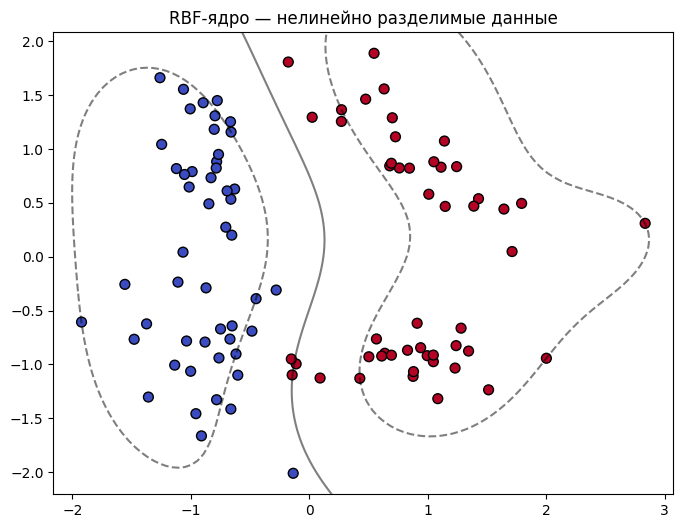

Точность (rbf): 0.980


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [8]:
# Пример для первого набора
plot_svm_decision_boundary(X3, y3, kernel='linear', title='Линейное ядро — нелинейно разделимые данные')
plot_svm_decision_boundary(X3, y3, kernel='poly', title='ПОлиномиальное ядро — нелинейно разделимые данные')
plot_svm_decision_boundary(X3, y3, kernel='rbf', title='RBF-ядро — нелинейно разделимые данные')

3.3. Повторите для наборов 2 и 3 с ядрами `'linear'`, `'rbf'`, `'poly'`. Сравните результаты.

### 4. Подбор гиперпараметров с GridSearchCV

Пример для одного набора данных:

In [9]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X1)

# Сетка параметров
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

# Поиск лучших параметров
grid = GridSearchCV(svm.SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_scaled, y1)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая точность:", grid.best_score_)

Лучшие параметры: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Лучшая точность: 1.0


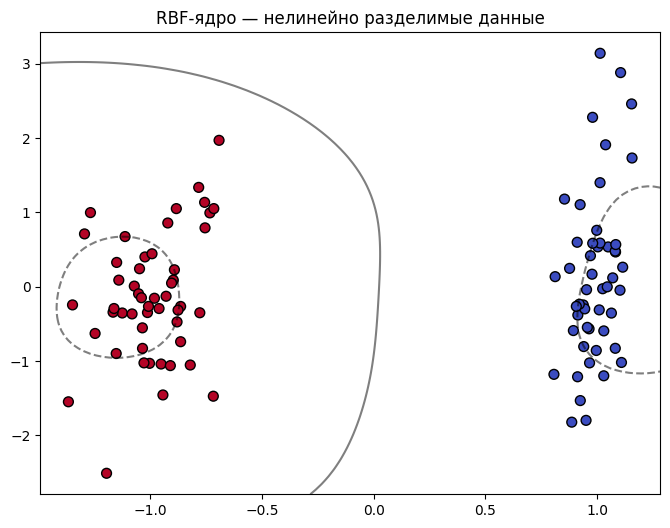

Точность (rbf): 1.000


,C,0.1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [10]:
plot_svm_decision_boundary(X1, y1, kernel='rbf', C = 0.1, gamma = 'scale', title='RBF-ядро — нелинейно разделимые данные')

Выполните подбор гиперпараметров для **набора данных 3** (нелинейного). Зафиксируйте результаты.

In [11]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X3)

# Сетка параметров
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

# Поиск лучших параметров
grid = GridSearchCV(svm.SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_scaled, y3)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая точность:", grid.best_score_)

Лучшие параметры: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Лучшая точность: 0.99


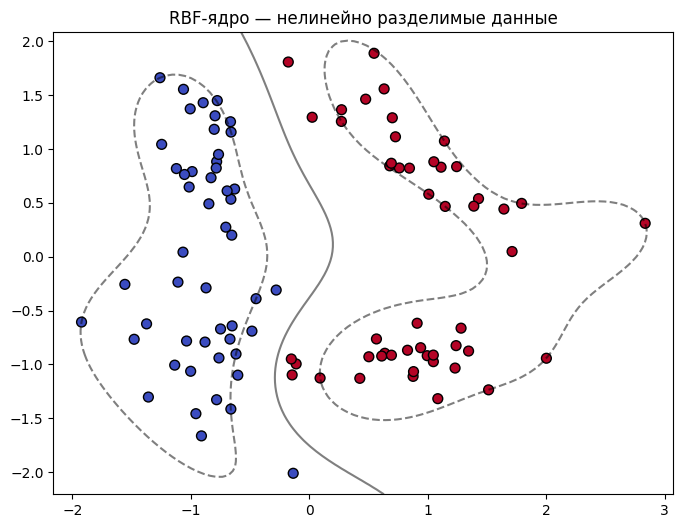

Точность (rbf): 1.000


,C,1
,kernel,'rbf'
,degree,3
,gamma,1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [12]:
plot_svm_decision_boundary(X3, y3, kernel='rbf', C = 1, gamma = 1, title='RBF-ядро — нелинейно разделимые данные')

### 5. Выводы

Добавьте ответы на вопросы и сформулируйте выводы по методу опорных векторов.

> **Вопрос 1:** Что такое опорный вектор и почему он важен?

> **Ответ:** Опорные вектора - объекты выборки, которые являются ближайшими к разделяющей плоскости -> они определяют итоговое положение разделяющей плоскости.

> **Вопрос 2:** В чём разница между линейным и нелинейным SVM?

> **Ответ:** Линейный SVM использует в качестве разделяющей плоскости линейную комбинацию признаков. Нелинейный SVM преобразует данные в пространство высшей размерности, где их можно линейно разделить.

> **Вопрос 3:** Как параметры C и gamma влияют на модель?

> **Ответ:** Параметр C - определяет компромисс между (расстоянием между гиперплоскостью и опорными векторами) и величиной ошибки. Параметр gamma - определяет влияние каждого объекта на итоговую плоскость.

> **Вопрос 4:** Почему важно масштабировать признаки перед обучением метода SVM?

> **Ответ:** Метод SVM зависит от расстояний между признаками -> для первоначальной равнозначности признаков